In [281]:
# -- imports and display settings --
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# inline plotting
%matplotlib inline  

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [312]:
# -- load data and initial checks --
df = pd.read_csv('tartu.csv')

print("First few rows :")
print(df.head())

print("\nShape: ", df.shape, '\n')

print("Data Types :\n", df.dtypes, '\n')

#missing values check
print("Missing values :\n", df.isnull().sum())


First few rows :
            start_time          finish_time  vehicle_start_lat  \
0  2023-06-16 04:20:50  2023-06-16 04:24:31          58.390856   
1  2023-06-16 04:20:52  2023-06-16 04:34:55          58.353762   
2  2023-06-16 14:09:42  2023-06-16 14:23:30          58.381312   
3  2023-06-16 14:18:36  2023-06-16 14:24:04          58.373844   
4  2023-06-16 15:27:09  2023-06-16 15:30:30          58.345220   

   vehicle_start_lng  vehicle_dropoff_lat  vehicle_dropoff_lng  ride_value  
0          26.729577            58.397929            26.736289        0.81  
1          26.680612            58.383613            26.708371        3.09  
2          26.751922            58.353977            26.726323        3.04  
3          26.749696            58.378362            26.726674        1.20  
4          26.715535            58.350316            26.723769        0.74  

Shape:  (328335, 7) 

Data Types :
 start_time              object
finish_time             object
vehicle_start_lat      fl

In [285]:
# -- clean missing coords --
print("Before cleaning statistics:\n")
print(df[['vehicle_dropoff_lat','vehicle_dropoff_lng','ride_value']].describe())

# Drop rows missing dropoff coordinates 
df_cleaned = df.dropna(subset = ['vehicle_dropoff_lat', 'vehicle_dropoff_lng'])

print(f"\nShape after dropping rows : {df_cleaned.shape}")

print("\nAfter clean statistics :\n")
print(df_cleaned[['vehicle_dropoff_lat','vehicle_dropoff_lng','ride_value']].describe())


Before cleaning statistics:

       vehicle_dropoff_lat  vehicle_dropoff_lng     ride_value
count        328209.000000        328209.000000  328335.000000
mean             58.356440            26.716827       1.594712
std               1.003470             0.459852       1.504647
min               0.000000             0.000000       0.000000
25%              58.369204            26.712817       0.770000
50%              58.376201            26.724886       1.250000
75%              58.380507            26.734821       1.970000
max              58.417113            26.809342      40.110000

Shape after dropping rows : (328209, 7)

After clean statistics :

       vehicle_dropoff_lat  vehicle_dropoff_lng     ride_value
count        328209.000000        328209.000000  328209.000000
mean             58.356440            26.716827       1.594799
std               1.003470             0.459852       1.504789
min               0.000000             0.000000       0.000000
25%              58.3

In [287]:
# -- remove zero drop-off coordinates --
df_cleaned = df_cleaned[(df_cleaned['vehicle_dropoff_lat'] != 0) & 
                        (df_cleaned['vehicle_dropoff_lng'] != 0)]

print(f"Shape after filtering zeros: {df_cleaned.shape}")

print(f"After zero dropoff stats: ")
print(df_cleaned[['vehicle_dropoff_lat','vehicle_dropoff_lng','ride_value']].describe())

Shape after filtering zeros: (328112, 7)
After zero dropoff stats: 
       vehicle_dropoff_lat  vehicle_dropoff_lng     ride_value
count        328112.000000        328112.000000  328112.000000
mean             58.373691            26.724725       1.594809
std               0.013655             0.021115       1.504805
min              58.300533            26.643321       0.000000
25%              58.369214            26.712837       0.770000
50%              58.376203            26.724893       1.250000
75%              58.380509            26.734827       1.970000
max              58.417113            26.809342      40.110000


In [289]:
# -- convert time columns to datetime --
df_cleaned['start_time'] = pd.to_datetime(df_cleaned['start_time'])
df_cleaned['finish_time'] = pd.to_datetime(df_cleaned['finish_time'])

print("Time columns coverted: ")
print(df_cleaned.dtypes[['start_time','finish_time']])


Time columns coverted: 
start_time     datetime64[ns]
finish_time    datetime64[ns]
dtype: object


In [291]:
# -- Extract date and hour from start time --
df_cleaned['date'] = df_cleaned['start_time'].dt.date
df_cleaned['hour'] = df_cleaned['start_time'].dt.hour

#new columns
print("Date and hour added: ")
print(df_cleaned[['start_time', 'date', 'hour']].head())

Date and hour added: 
           start_time        date  hour
0 2023-06-16 04:20:50  2023-06-16     4
1 2023-06-16 04:20:52  2023-06-16     4
2 2023-06-16 14:09:42  2023-06-16    14
3 2023-06-16 14:18:36  2023-06-16    14
4 2023-06-16 15:27:09  2023-06-16    15


In [293]:
# -- Final cleaned DataFrame --
df_cleaned.info()

print("\nSample of cleaned data: ")
print(df_cleaned.head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 328112 entries, 0 to 328334
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   start_time           328112 non-null  datetime64[ns]
 1   finish_time          328112 non-null  datetime64[ns]
 2   vehicle_start_lat    328112 non-null  float64       
 3   vehicle_start_lng    328112 non-null  float64       
 4   vehicle_dropoff_lat  328112 non-null  float64       
 5   vehicle_dropoff_lng  328112 non-null  float64       
 6   ride_value           328112 non-null  float64       
 7   date                 328112 non-null  object        
 8   hour                 328112 non-null  int32         
dtypes: datetime64[ns](2), float64(5), int32(1), object(1)
memory usage: 23.8+ MB

Sample of cleaned data: 
           start_time         finish_time  vehicle_start_lat  \
0 2023-06-16 04:20:50 2023-06-16 04:24:31          58.390856   
1 2023-06-16 04:20:52

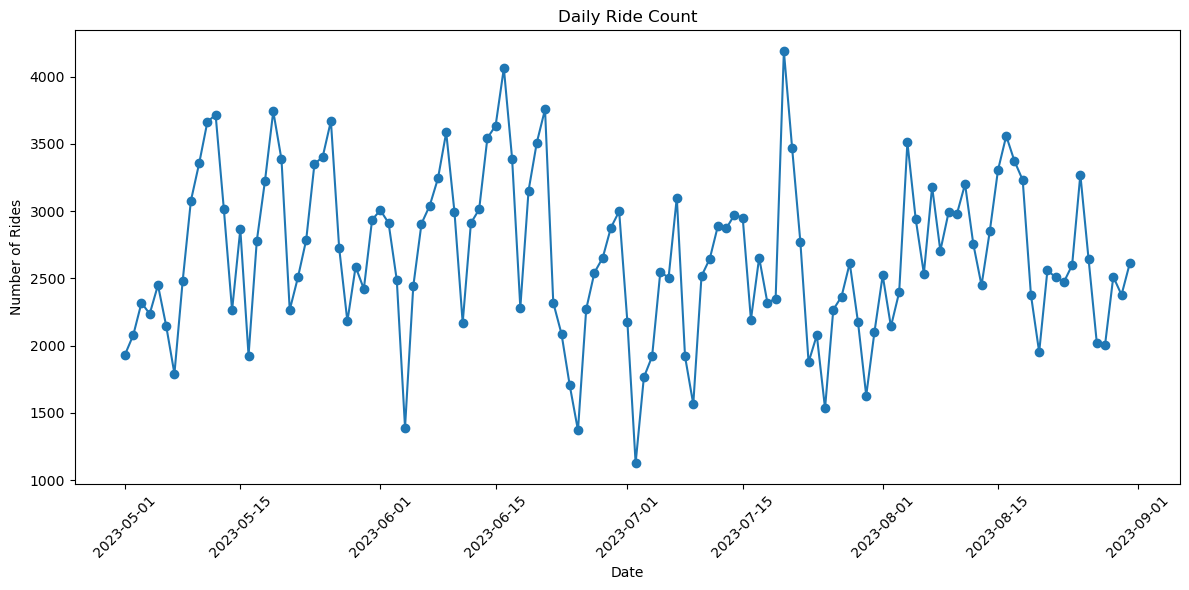

In [214]:
# -- Daily ride counts --
daily_rides = df_cleaned.groupby("date").size()

#plot 
plt.figure(figsize=(12, 6))
plt.plot(daily_rides.index, daily_rides.values, marker='o')
plt.title("Daily Ride Count")
plt.xlabel("Date")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


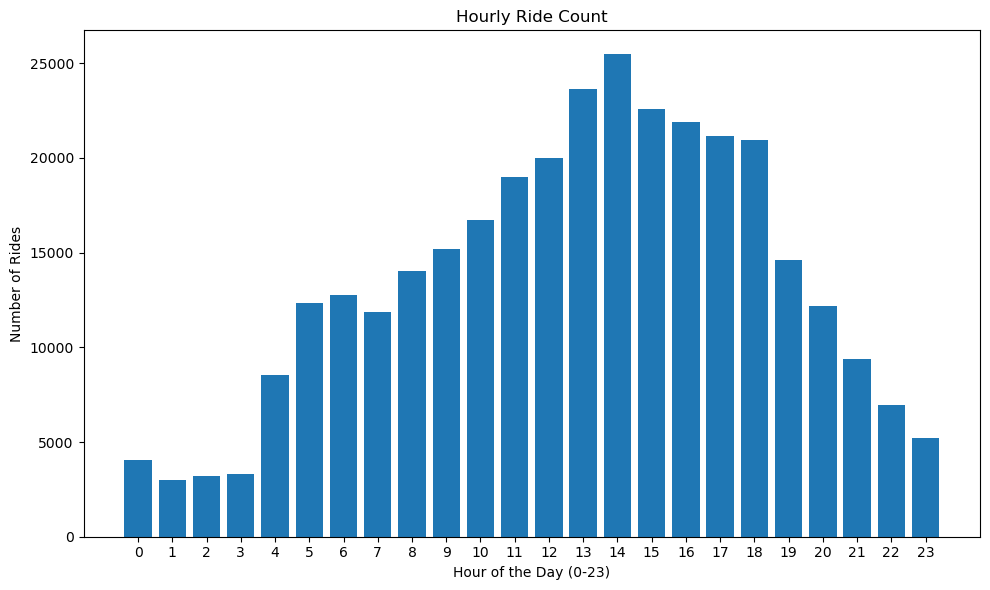

In [295]:
# -- Hourly ride counts --
hourly_rides = df_cleaned.groupby("hour").size()

# Plot
plt.figure(figsize=(10, 6))
plt.bar(hourly_rides.index, hourly_rides.values)
plt.title("Hourly Ride Count")
plt.xlabel("Hour of the Day (0-23)")
plt.ylabel("Number of Rides")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [297]:
# -- Daily ride stats --
daily = df_cleaned.groupby('date').size()

#avg, lowest and highest ride per day
daily_avg = daily.mean() 
daily_min = daily.min()
daily_max = daily.max()

print(f"Average daily rides: {daily_avg:.0f}")
print(f"Range of daily rides: {daily_min:.0f} - {daily_max:.0f}")

# total rides per hour
hourly = df_cleaned.groupby('hour').size()

# Top 5 busiest hours
print("Busiest hours:")
print(hourly.nlargest(5).to_string())

# 5 quietest hours
print("\nQuietest hours:")
print(hourly.nsmallest(5).to_string())

Average daily rides: 2668
Range of daily rides: 1126 - 4191
Busiest hours:
hour
14    25461
13    23651
15    22598
16    21898
17    21171

Quietest hours:
hour
1     3007
2     3191
3     3312
0     4073
23    5202


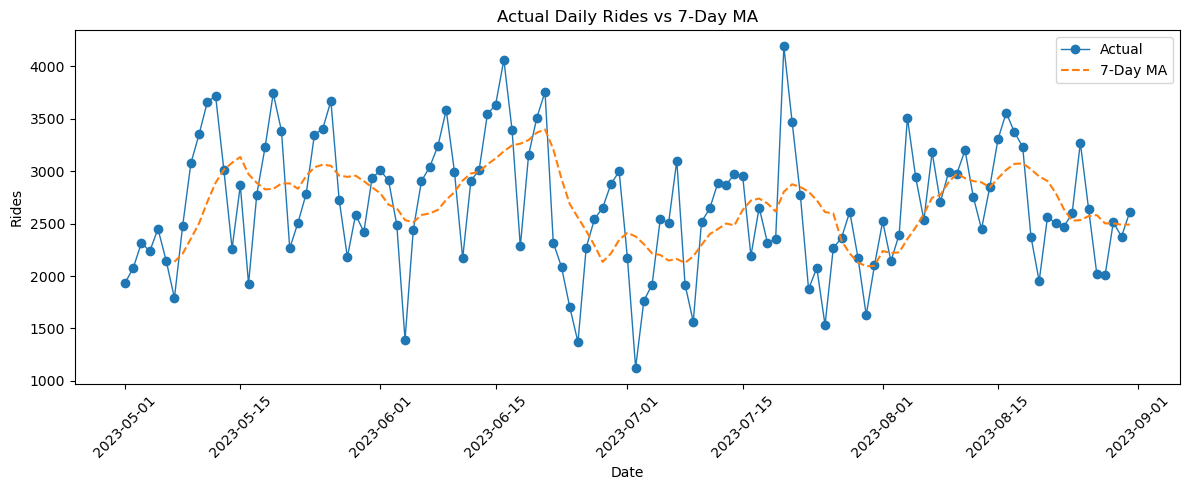

7-Day MA RMSE: 545 rides
Forecast for 2023-09-01: 2491 rides


In [230]:
# -- 7 day MA forecast --

#compute daily counts and 7 day moving average
daily = df_cleaned.groupby("date").size()
ma7 = daily.rolling(window = 7).mean()

# plot actual vs MA7
plt.figure(figsize=(12,5))
plt.plot(daily.index, daily.values, label = "Actual", marker = 'o', linewidth = 1)
plt.plot(ma7.index, ma7.values, label = "7-Day MA", linestyle = '--')
plt.title("Actual Daily Rides vs 7-Day MA")
plt.xlabel("Date")
plt.ylabel("Rides")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# skip first 6 NaNs in MA, pandas needs 7 data points to calculate the first average
actual   = daily.iloc[6:]
forecast = ma7.iloc[6:]

# compue RMSE 
mse = mean_squared_error(actual, forecast)
rmse = math.sqrt(mse)
print(f"7-Day MA RMSE: {rmse:.0f} rides")

# Forecast next day from last MA value
last_ts  = pd.to_datetime(daily.index[-1])
next_day = last_ts + pd.Timedelta(days=1)
print(f"Forecast for {next_day.date()}: {ma7.iloc[-1]:.0f} rides")



**EDA Summary**

- **Daily volume:** We can see an average of about 2700 rides per day on an average, ranging from about 1100 to 4200 in the quietest and busiest days 
- **Weekly Trend:** The daily ride chart shows a clear 7 day weekly cycle ride counts, build steadily monday through friday and then dip over the weekend
- **Hourly pattern:** Highest ride demand is at 14.00 (around 25500 rides), followed by 13.00, 15.00, 16.00. Quietest hours happen in the early morning, especially around 1.00 - 3.00 (about 3007).  
- **Spatial concentration:** From our 10 * 10 spatial binning, the majority of pickups occur in grid cells (6, 4) and (6, 5) which is the central downtown area of Tartu.  

In [299]:
# -- Spatial analysis: average hourly pickups per grid cell --

#define 10*10 grid edges over start locations
lat_bins = np.linspace(df_cleaned['vehicle_start_lat'].min(), df_cleaned['vehicle_start_lat'].max(), 11)
lng_bins = np.linspace(df_cleaned['vehicle_start_lng'].min(), df_cleaned['vehicle_start_lng'].max(), 11)

# label each ride by which bin it falls into
df_cleaned ['lat_bin'] = pd.cut(df_cleaned['vehicle_start_lat'], bins = lat_bins, labels = False)
df_cleaned ['lng_bin'] = pd.cut(df_cleaned['vehicle_start_lng'], bins = lng_bins, labels = False)

#count rides per (lat_bin, lng_bin, hour)
zone_hour = (df_cleaned
             .groupby(['lat_bin', 'lng_bin', 'hour'])
             .size()
             .reset_index(name = 'count'))

print("Zone‑hour sample:")
print(zone_hour.head())

#top 3 zones per hour
top3_per_hour =(
    zone_hour
    .sort_values(['hour', 'count'], ascending=[True, False])
    .groupby('hour', group_keys=False)
    .head(3)
    .reset_index(drop=True))

print("Top 3 zones for each hour:")
print(top3_per_hour)

Zone‑hour sample:
   lat_bin  lng_bin  hour  count
0      0.0      2.0     3      4
1      0.0      2.0     4      3
2      0.0      2.0     5      6
3      0.0      2.0     6      2
4      0.0      2.0     7      4
Top 3 zones for each hour:
    lat_bin  lng_bin  hour  count
0       6.0      4.0     0   1396
1       6.0      5.0     0    705
2       7.0      4.0     0    379
3       6.0      4.0     1    987
4       6.0      5.0     1    510
5       7.0      4.0     1    209
6       6.0      4.0     2    532
7       6.0      5.0     2    415
8       6.0      6.0     2    301
9       6.0      4.0     3    364
10      6.0      5.0     3    359
11      5.0      5.0     3    307
12      6.0      4.0     4    929
13      6.0      5.0     4    788
14      6.0      3.0     4    667
15      6.0      5.0     5   1454
16      6.0      4.0     5   1389
17      6.0      3.0     5   1152
18      6.0      4.0     6   1771
19      6.0      5.0     6   1652
20      6.0      3.0     6   1081
21      6

In [268]:
# -- Build and display dispatch plan --
#based on top 3 zones per hour
qty_map = {1: 5, 2:3, 3:1}
dispatch_plan = []

for hour, grp in top3_per_hour.groupby('hour', sort = True):
    for rank, entry in enumerate(grp.itertuples(index = False), start=1):
        dispatch_plan.append({"hour" : hour, 
                              "lat_bin": entry.lat_bin, 
                              "lng_bin": entry.lng_bin, 
                              "scooters": qty_map[rank]})
dispatch_df = pd.DataFrame(dispatch_plan)

# Print per hour dispatch blocks
for hour, grp in dispatch_df.groupby('hour', sort = True):
    print(f"\n--- Hour {hour:02d} ---")
    print(grp[['lat_bin','lng_bin','scooters']].to_string(index = False))

print("Total dispatch entries:", len(dispatch_df))  # should be 72(24 * 3


--- Hour 00 ---
 lat_bin  lng_bin  scooters
     6.0      4.0         5
     6.0      5.0         3
     7.0      4.0         1

--- Hour 01 ---
 lat_bin  lng_bin  scooters
     6.0      4.0         5
     6.0      5.0         3
     7.0      4.0         1

--- Hour 02 ---
 lat_bin  lng_bin  scooters
     6.0      4.0         5
     6.0      5.0         3
     6.0      6.0         1

--- Hour 03 ---
 lat_bin  lng_bin  scooters
     6.0      4.0         5
     6.0      5.0         3
     5.0      5.0         1

--- Hour 04 ---
 lat_bin  lng_bin  scooters
     6.0      4.0         5
     6.0      5.0         3
     6.0      3.0         1

--- Hour 05 ---
 lat_bin  lng_bin  scooters
     6.0      5.0         5
     6.0      4.0         3
     6.0      3.0         1

--- Hour 06 ---
 lat_bin  lng_bin  scooters
     6.0      4.0         5
     6.0      5.0         3
     6.0      3.0         1

--- Hour 07 ---
 lat_bin  lng_bin  scooters
     6.0      4.0         5
     6.0      5.0       

**Vehicle Reallocation Strategy:**

Based on each hour's top 3 busiest zones (from 'top3_per_hour):

- zone 1: Dispatch 5 extra scooters  
- zone 2: Dispatch 3 extra scooters  
- zone 3: Dispatch 1 extra scooter  

This “5-3-1” matches supply to demand:
- Send 5 extra scooters to the busiest zone, 3 to the second‑busiest, and 1 to the third.  
- If you have more scooters overall, you can start with a higher number (or reduce it if you have fewer).  

## Assumptions, Caveats & Next Steps

- **Weekly patterns:** I’m assuming demand repeats every week, but holidays or special events may break this.  
- **Ignored factors:** Right now we’re not using weather(rain, temperature), battery levels, or live traffic—any of those could change demand.  
- **Further improvements:**
  1. Add weather and event data so we can adjust before rain, heatwaves, or concerts.  
  2. Check scooter battery and maintenance to only send scooters that are ready.  
  3. Plan moves so drivers stay within their shift hours and scooters have time to charge.  
  4. Build a dashboard that shares hourly dispatch plans with the operations team.  
  5. Use real‑time alerts to spot sudden demand spikes (like concerts or transit delays).  
  6. Track cancellations to tell real demand from failed rides.  
  